In [3]:
import sys

import os
sys.path.append(os.path.abspath('../'))

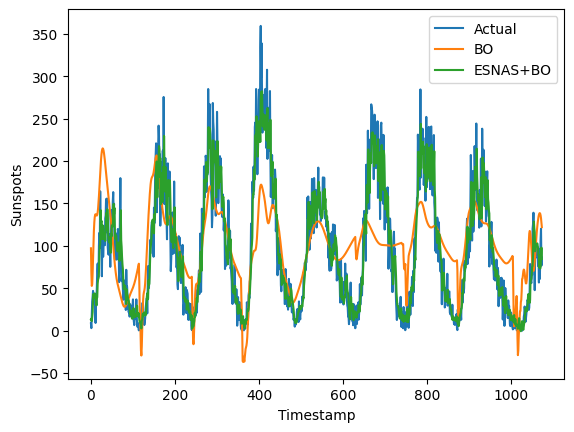

In [3]:

from NAS.error_metrics import r_squared, nrmse
from NAS.utils import runModel
from experiments.hybrid import nrmse_sunspots
from utils import readSavedExperiment
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def getDataSunspots():
    sunspots = pd.read_csv("../datasets/Sunspots.csv")
    data = sunspots.loc[:,"Monthly Mean Total Sunspot Number"].to_numpy()
    data = np.expand_dims(data, axis=1)

    trainLen = 1600
    valLen = 500
    testLen = 1074
    train_in = data[0:trainLen]
    train_out = data[0+1:trainLen+1]
    val_in = data[trainLen:trainLen+valLen]
    val_out = data[trainLen+1:trainLen+valLen+1]
    test_in = data[trainLen+valLen:trainLen+valLen+testLen]
    test_out = data[trainLen+valLen+1:trainLen+valLen+testLen+1]
    return train_in, train_out, val_in, val_out, test_in, test_out

_, _, _, _, testX, testY = getDataSunspots()
nrmseErrors = []
rSquaredValues = []
bo = readSavedExperiment('../backup_bo/sunspots/backup_{}.obj'.format(4))
hybrid = readSavedExperiment('../backup_hybrid/sunspots/backup_3.obj')
model = bo.bestModel
hybrid_model = hybrid.bestModel
preds = runModel(model, testX)
preds_hybrid = runModel(hybrid_model, testX)
plt.plot(testY)
plt.plot(preds)
plt.plot(preds_hybrid)
plt.xlabel("Timestamp")
plt.ylabel("Sunspots")
plt.legend(['Actual', 'BO', 'ESNAS+BO'], loc='upper right')

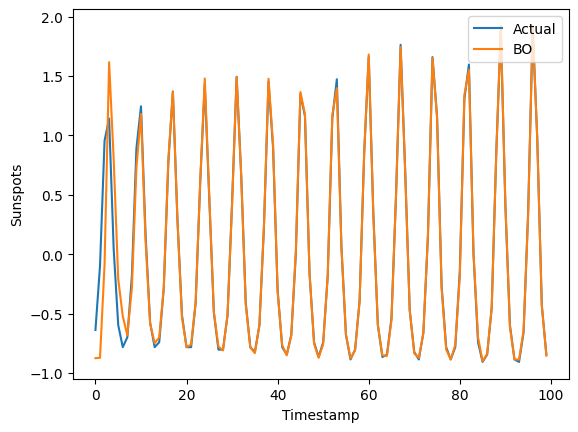

In [15]:
def getDataLaser():
    sunspots = pd.read_csv("../data/santafelaser.csv")
    data = np.array(sunspots)
    data = data.reshape((data.shape[0],1))
    data = data[:3801,:]
    from scipy import stats
    data = stats.zscore(data)

    trainLen = 2000
    valLen = 100
    testLen = 100
    train_in = data[0:trainLen]
    train_out = data[0+1:trainLen+1]
    val_in = data[trainLen:trainLen+valLen]
    val_out = data[trainLen+1:trainLen+valLen+1]
    test_in = data[trainLen+valLen:trainLen+valLen+testLen]
    test_out = data[trainLen+valLen+1:trainLen+valLen+testLen+1]
    return train_in, train_out, val_in, val_out, test_in, test_out

_, _, testX, testY, _, _ = getDataLaser()
nrmseErrors = []
rSquaredValues = []
bo = readSavedExperiment('../backup_bo/laser/backup_{}.obj'.format(4))
# hybrid = readSavedExperiment('../backup_hybrid/sunspots/backup_3.obj')
model = bo.bestModel
# hybrid_model = hybrid.bestModel
preds = runModel(model, testX)
# preds_hybrid = runModel(hybrid_model, testX)
plt.plot(testY)
plt.plot(preds)
# plt.plot(preds_hybrid)
plt.xlabel("Timestamp")
plt.ylabel("Sunspots")
plt.legend(['Actual', 'BO'], loc='upper right')

In [19]:
from NAS.error_metrics import r_squared, nrmse

r_squared(testY, preds)

0.9615580236805329

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_esn_architecture(architecture):
    lastNode = len(architecture['nodes']) - 1
    architecture['nodes'].append({'type': 'Output'})
    architecture['edges'].append([lastNode, lastNode+1])
    G = nx.DiGraph()
    
    # Add nodes
    for i, node in enumerate(architecture['nodes']):
        G.add_node(i, **node)
    
    G.add_edges_from(architecture['edges'])
    
    # Compute node levels (x-coordinates)
    levels = {}
    def dfs(node, level):
        if node not in levels:
            levels[node] = level
            for neighbor in G.neighbors(node):
                dfs(neighbor, level + 1)
    
    # Start DFS from input nodes (nodes with in_degree 0)
    input_nodes = [node for node in G.nodes() if G.in_degree(node) == 0]
    for input_node in input_nodes:
        dfs(input_node, 0)
    
    # Compute node positions
    pos = {}
    level_counts = {}
    for node, level in levels.items():
        if level not in level_counts:
            level_counts[level] = 0
        y = level_counts[level]
        level_counts[level] += 1
        pos[node] = (level, -y)  # Negative y to have top-to-bottom layout
    
    # Set up the plot
    plt.figure(figsize=(12, 8))
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue')
    
    # Draw edges with arrows
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, 
                           arrowsize=20, arrowstyle='wedge', connectionstyle='arc3,rad=0')
    
    # Add labels (only node type)
    labels = {i: data['type'] for i, data in G.nodes(data=True)}
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight="bold")
    
    # Set title and remove axis
    plt.title("Echo State Network Architecture", fontsize=16)
    plt.axis('off')
    
    # Show the plot
    plt.tight_layout()
    plt.show()

In [5]:
from NAS.ESN_NAS import ESN_NAS
from NAS.ESN_NAS2 import ESN_NAS2
from NAS.ESN_BO import ESN_BO
from NAS.error_metrics import nrmse, r_squared
from utils import readSavedExperiment
import numpy as np

def findBestGaArchitecture(ga: ESN_NAS):
    errors = [errors[0] for errors in ga.fitnesses]
    gaBestError = min(errors)
    gaBestErrorIndex = errors.index(gaBestError)
    gaBestModel = ga.architectures[gaBestErrorIndex]
    return gaBestModel, gaBestError

def findBestGasArchitecture(gas: list[ESN_NAS]):
    bestError = np.inf
    bestArchitecture = None
    for ga in gas:
        architecture, error = findBestGaArchitecture(ga)
        if error<bestError:
            bestArchitecture = architecture
    return bestArchitecture


<Figure size 500x500 with 0 Axes>

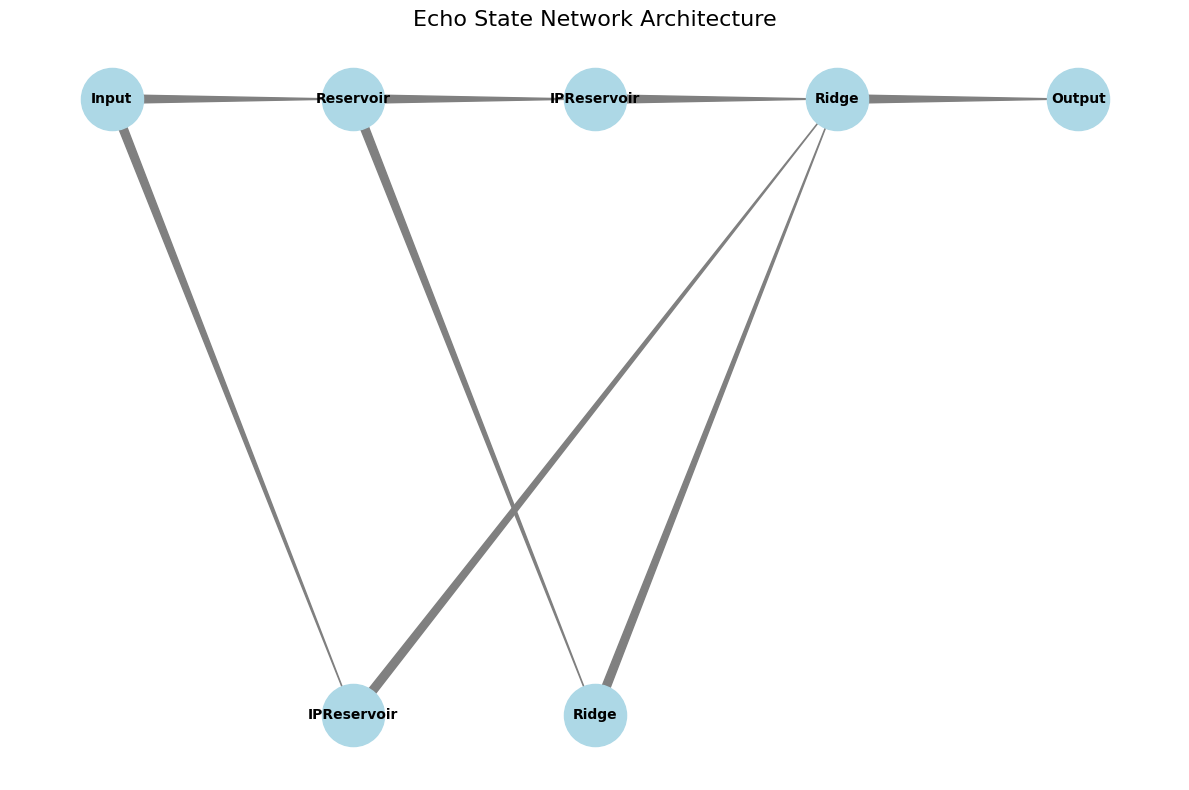

In [15]:
gas = [readSavedExperiment(f'../backup_50/mgs/backup_{i}.obj') for i in range(5)]
architecture = findBestGasArchitecture(gas)
visualize_esn_architecture(architecture)

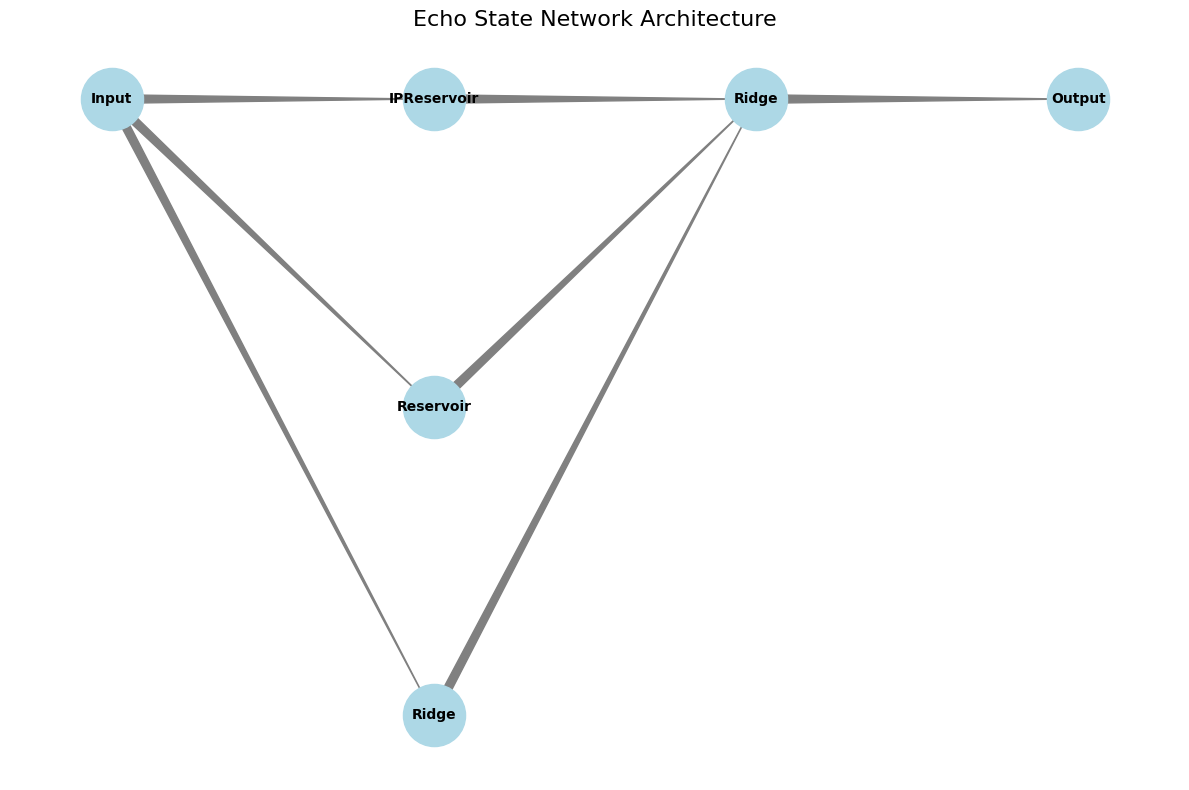

In [61]:
gas = [readSavedExperiment(f'../backup_50/dde/backup_{i}.obj') for i in range(5)]
architecture = findBestGasArchitecture(gas)
visualize_esn_architecture(architecture)

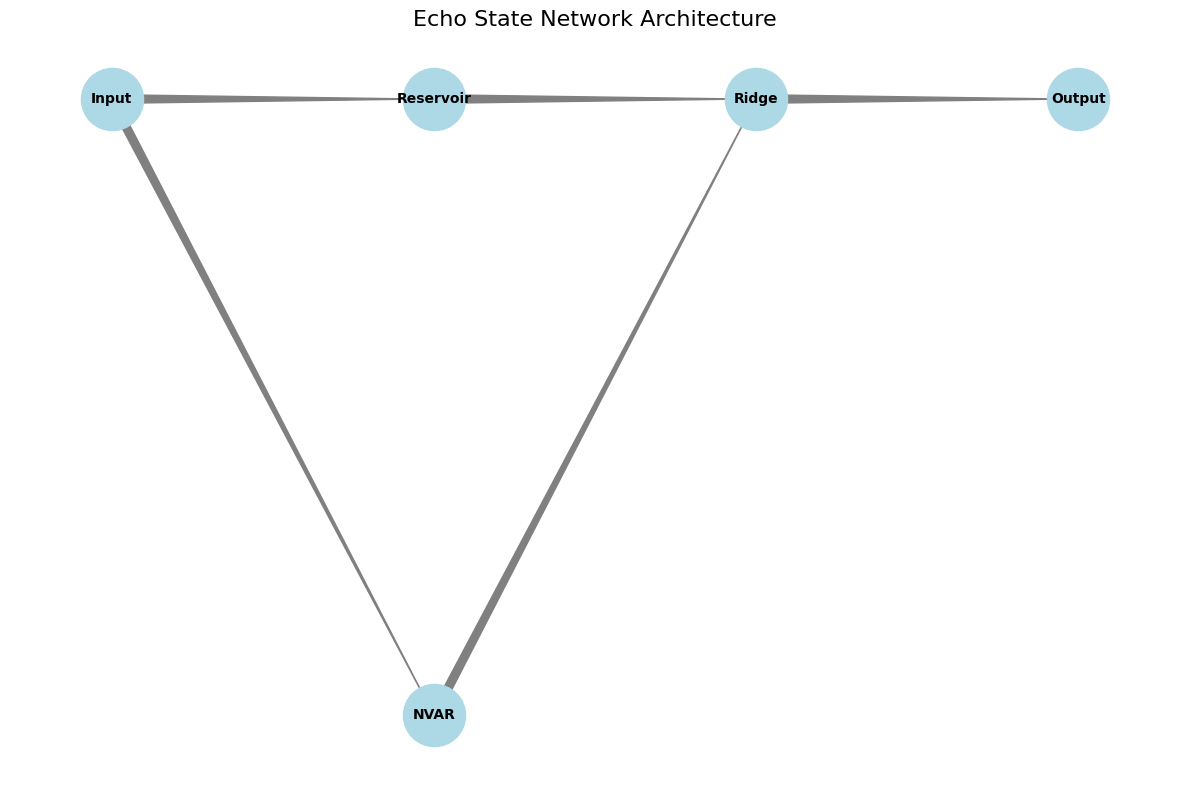

In [62]:
gas = [readSavedExperiment(f'../backup_50/laser/backup_{i}.obj') for i in range(5)]
architecture = findBestGasArchitecture(gas)
visualize_esn_architecture(architecture)

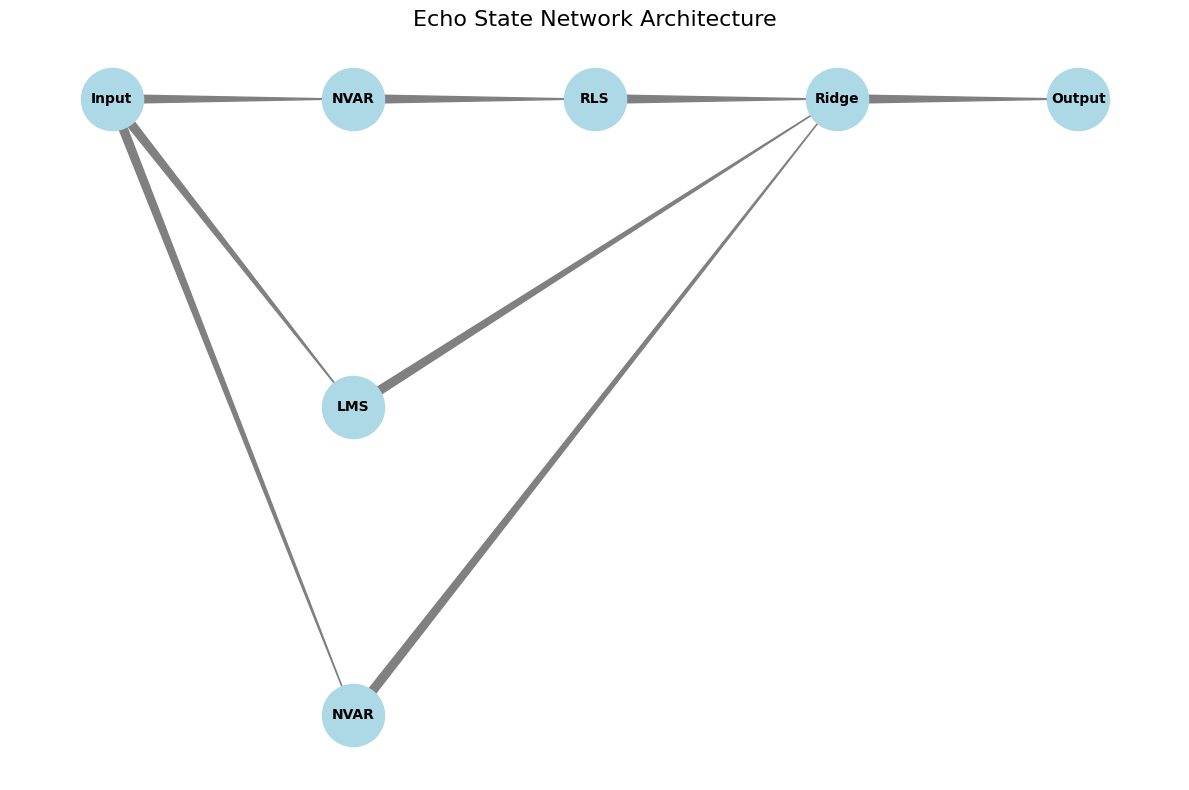

In [63]:
gas = [readSavedExperiment(f'../backup_50/lorenz/backup_{i}.obj') for i in range(5)]
architecture = findBestGasArchitecture(gas)
visualize_esn_architecture(architecture)

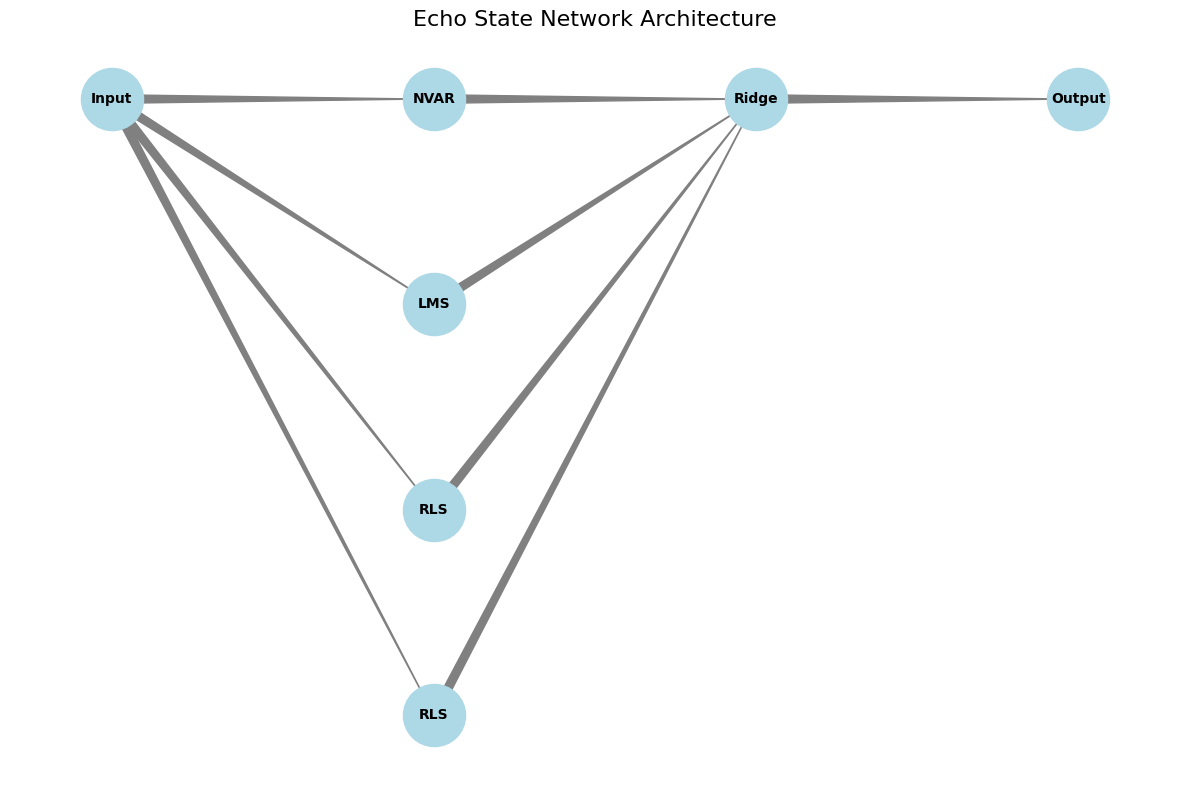

In [64]:
gas = [readSavedExperiment(f'../backup_50/water/backup_{i}.obj') for i in range(5)]
architecture = findBestGasArchitecture(gas)
visualize_esn_architecture(architecture)

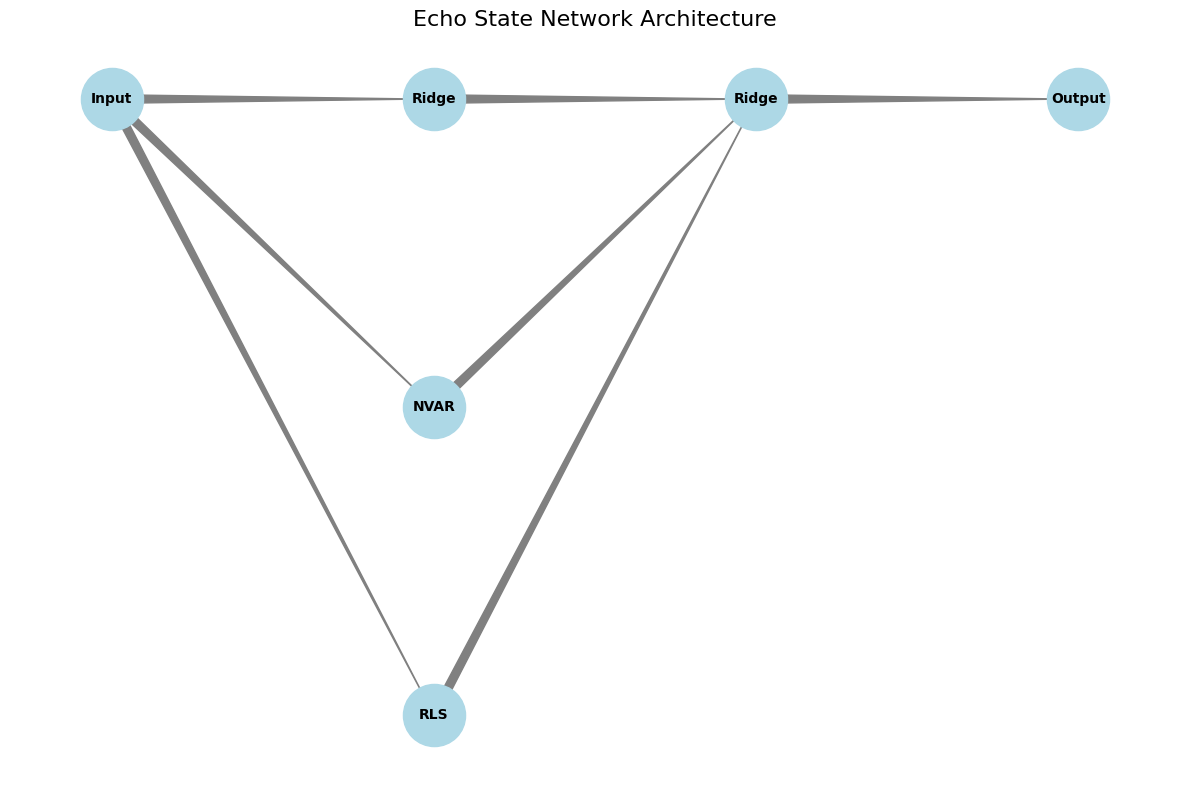

In [65]:
gas = [readSavedExperiment(f'../backup_50/sunspots/backup_{i}.obj') for i in range(5)]
architecture = findBestGasArchitecture(gas)
visualize_esn_architecture(architecture)

In [10]:
import matplotlib.pyplot as plt
from utils import readSavedExperiment

def plotConvergences(dataset, save_location_ga, save_location_bo, title, max_y_axis=3, min_y_axis=0):
    gas: list[ESN_NAS2] = [readSavedExperiment(f'../{save_location_ga}/{dataset}/backup_{i}.obj') for i in range(5)]
    bos: list[ESN_BO] = [readSavedExperiment(f'../{save_location_bo}/{dataset}/backup_{i}.obj') for i in range(5)]
    colors = ['blue', 'red', 'green', 'purple', 'orange']
    for idx, ga in enumerate(gas):
        allNrmse = [error[0] for error in ga.fitnesses]
        nrmseFitnesses = []
        fitnessIndexStart = 0
        for i in range(ga.gaParams.generations+1):
            generationEndIndex = fitnessIndexStart + ga.gaParams.populationSize + 49 if i in ga.modelGenerationIndices and i>0 else fitnessIndexStart + ga.gaParams.populationSize
            generationNrmses = allNrmse[fitnessIndexStart:generationEndIndex]
            fitnessIndexStart = generationEndIndex
            generationBestNrmse = min(generationNrmses) if len(generationNrmses)>0 else min(nrmseFitnesses)
            bestNrmse = min([generationBestNrmse, min(nrmseFitnesses)]) if len(nrmseFitnesses)>0 else generationBestNrmse
            nrmseFitnesses.append(bestNrmse)
        
        print(min(nrmseFitnesses))
        bo = bos[idx]
        allNrmseBO = [error[0] for error in bo.performances]
        maxImprovementIndex = 0
        bestPerformance = 1
        for i, error in enumerate(allNrmseBO):
            if error<bestPerformance:
                bestPerformance = error
                maxImprovementIndex = i
        formattedBONrmse = []
        populationSize = int((bo.n_rand + bo.iterations) / ga.gaParams.generations)
        for i in range(ga.gaParams.generations):
            formattedBONrmse.append(min(allNrmseBO[i*populationSize:(i+1)*populationSize]))
        minBoFitness = formattedBONrmse[0]
        boFitnesses = []
        for fitness in formattedBONrmse:
            if fitness<minBoFitness:
                minBoFitness = fitness
            boFitnesses.append(minBoFitness)
        plt.plot(nrmseFitnesses, 'b-', color=colors[idx])
        # plt.plot(boFitnesses, 'b--', color=colors[idx])
    plt.title(title)
    plt.xlabel("Generation")
    plt.ylabel("NRMSE")
    plt.ylim(min_y_axis, max_y_axis)
    plt.show()

0.026665459533179982
0.052984572418516986
0.07198699554732285
0.04925482401142749
0.03276149856807871


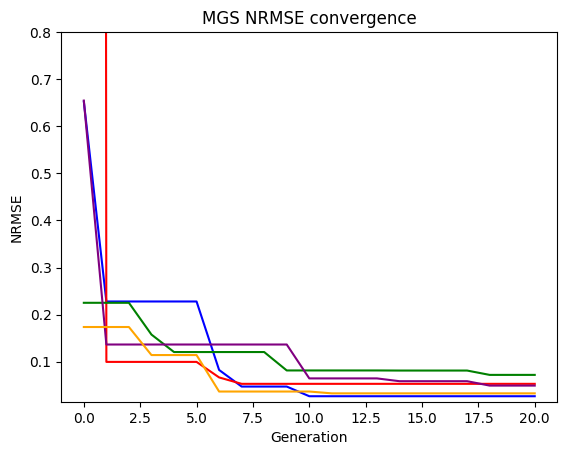

0.00047825856326018834
0.0003011064349900113
0.007592868490466063
0.008247061890382113
0.0008897102847966863


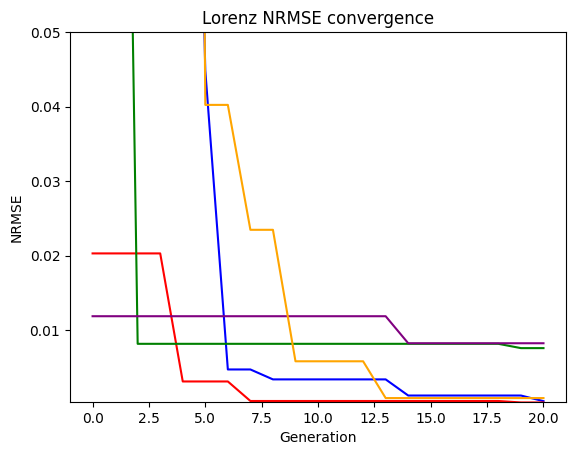

1.9299948713697217
2.298349382035729
2.4527623323725956
2.273755166480416
2.2011670056697707


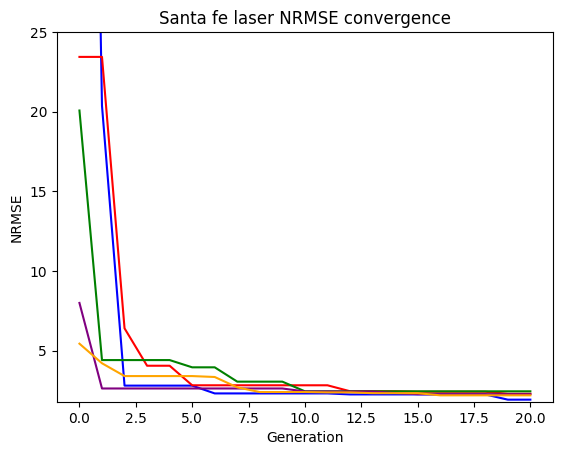

0.0011377353002664586
0.0009321195760060427
0.0016571617948915758
0.0007542121547629125
0.0020434630019889144


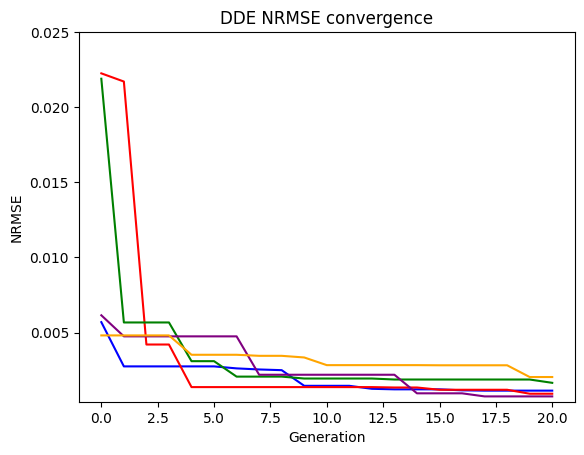

0.46797482189667755
0.4703516018533742
0.46617228016997003
0.4692335538031513
0.47081994719913906


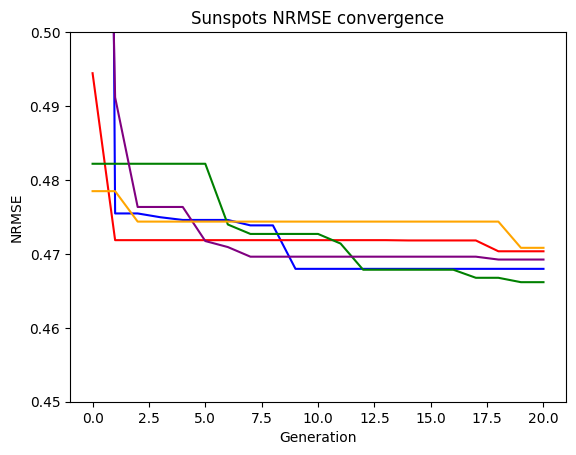

0.045392658957923666
0.046656097544721685
0.04093868182556001
0.04563731547877796
0.04455248661242525


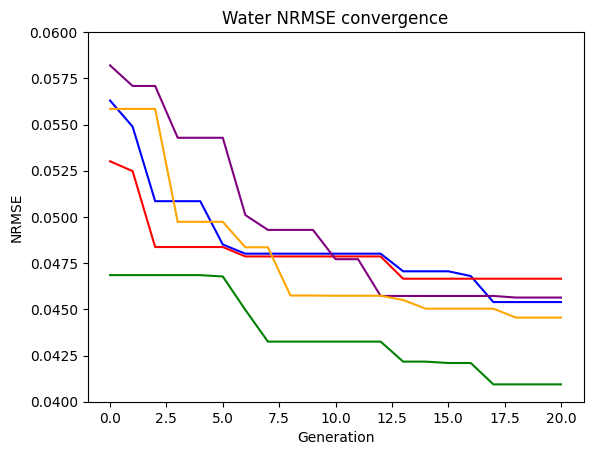

In [11]:
plotConvergences('mgs', 'hybrid2', 'backup_bo2', "MGS NRMSE convergence", 0.8, 0.015)
plotConvergences('lorenz', 'hybrid2', 'backup_bo2', "Lorenz NRMSE convergence", 0.05, 0.0004)
plotConvergences('laser', 'hybrid2', 'backup_bo2', "Santa fe laser NRMSE convergence", 25, 1.8)
plotConvergences('dde', 'hybrid2', 'backup_bo2', "DDE NRMSE convergence", 0.025, 0.0004)
plotConvergences('sunspots', 'hybrid2_sunspots_tests', 'backup_bo2', "Sunspots NRMSE convergence", 0.5, 0.45)
plotConvergences('water', 'hybrid2_small_models', 'backup_bo2', "Water NRMSE convergence", 0.06, 0.04)

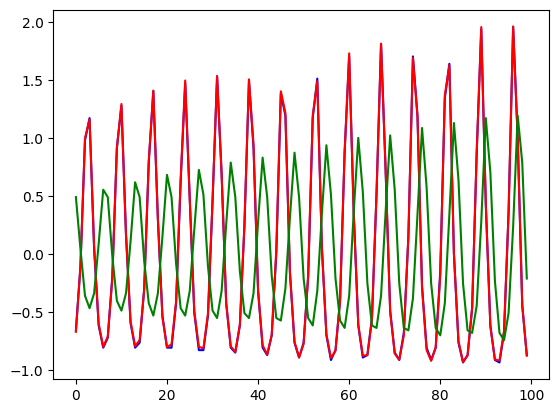

In [20]:
target = [[-0.65528285],
 [-0.10274454],
 [ 0.98108061],
 [ 1.17234387],
 [ 0.04601578],
 [-0.6127799 ],
 [-0.80404316],
 [-0.71903727],
 [-0.18775043],
 [ 0.91732619],
 [ 1.27860123],
 [ 0.17352462],
 [-0.59152843],
 [-0.80404316],
 [-0.76154022],
 [-0.2940078 ],
 [ 0.78981735],
 [ 1.40611008],
 [ 0.30103346],
 [-0.52777401],
 [-0.80404316],
 [-0.80404316],
 [-0.42151664],
 [ 0.61980556],
 [ 1.4698645 ],
 [ 0.47104524],
 [-0.50652253],
 [-0.82529464],
 [-0.82529464],
 [-0.52777401],
 [ 0.44979377],
 [ 1.53361892],
 [ 0.68355998],
 [-0.42151664],
 [-0.80404316],
 [-0.84654611],
 [-0.6127799 ],
 [ 0.23727904],
 [ 1.49111597],
 [ 0.91732619],
 [-0.31525927],
 [-0.80404316],
 [-0.86779758],
 [-0.6977858 ],
 [ 0.00351283],
 [ 1.3848586 ],
 [ 1.19359534],
 [-0.16649896],
 [-0.76154022],
 [-0.88904906],
 [-0.76154022],
 [-0.18775043],
 [ 1.17234387],
 [ 1.51236744],
 [ 0.06726725],
 [-0.6977858 ],
 [-0.91030053],
 [-0.82529464],
 [-0.40026517],
 [ 0.87482324],
 [ 1.7036307 ],
 [ 0.36478788],
 [-0.6127799 ],
 [-0.88904906],
 [-0.86779758],
 [-0.54902548],
 [ 0.51354819],
 [ 1.80988807],
 [ 0.72606293],
 [-0.48527106],
 [-0.84654611],
 [-0.91030053],
 [-0.67653432],
 [ 0.15227314],
 [ 1.7036307 ],
 [ 1.19359534],
 [-0.27275633],
 [-0.80404316],
 [-0.91030053],
 [-0.80404316],
 [-0.14524749],
 [ 1.34235565],
 [ 1.63987628],
 [ 0.00351283],
 [-0.76154022],
 [-0.931552  ],
 [-0.86779758],
 [-0.46401959],
 [ 0.87482324],
 [ 1.93739691],
 [ 0.4285423 ],
 [-0.6127799 ],
 [-0.91030053],
 [-0.931552  ],
 [-0.67653432],
 [ 0.36478788],
 [ 1.95864838],
 [ 1.00233208],
 [-0.44276811],
 [-0.86779758]]

esnas_preds = [[-0.66755388],
 [-0.10581337],
 [ 0.99972355],
 [ 1.16171757],
 [ 0.07372778],
 [-0.59677088],
 [-0.79684598],
 [-0.70815859],
 [-0.20992323],
 [ 0.91526182],
 [ 1.29390884],
 [ 0.16443299],
 [-0.57663021],
 [-0.79208415],
 [-0.73815845],
 [-0.3039776 ],
 [ 0.80761222],
 [ 1.40912066],
 [ 0.30910268],
 [-0.54465852],
 [-0.79965044],
 [-0.77498575],
 [-0.40482959],
 [ 0.64961892],
 [ 1.49615104],
 [ 0.47688554],
 [-0.49128652],
 [-0.79714141],
 [-0.81028917],
 [-0.51000639],
 [ 0.46209674],
 [ 1.53314165],
 [ 0.68842831],
 [-0.4212505 ],
 [-0.79263128],
 [-0.84151077],
 [-0.60708768],
 [ 0.25481273],
 [ 1.50622899],
 [ 0.94348323],
 [-0.31155375],
 [-0.78269209],
 [-0.86396535],
 [-0.69250925],
 [ 0.03812609],
 [ 1.40285734],
 [ 1.2160417 ],
 [-0.15224592],
 [-0.75466   ],
 [-0.88762099],
 [-0.77171031],
 [-0.18807264],
 [ 1.19561062],
 [ 1.49031101],
 [ 0.06274868],
 [-0.68837473],
 [-0.89242482],
 [-0.83014191],
 [-0.39776909],
 [ 0.87839595],
 [ 1.72990309],
 [ 0.34973744],
 [-0.60422571],
 [-0.87270657],
 [-0.86845703],
 [-0.56463706],
 [ 0.51677605],
 [ 1.81345516],
 [ 0.72889524],
 [-0.49386046],
 [-0.85499775],
 [-0.90750746],
 [-0.6987613 ],
 [ 0.15014801],
 [ 1.69103796],
 [ 1.18376321],
 [-0.29406661],
 [-0.8250518 ],
 [-0.91767216],
 [-0.80238151],
 [-0.18640352],
 [ 1.36894072],
 [ 1.62587812],
 [ 0.00399916],
 [-0.74661031],
 [-0.92735057],
 [-0.87094976],
 [-0.45902526],
 [ 0.87420138],
 [ 1.95611686],
 [ 0.42953769],
 [-0.62185105],
 [-0.90620643],
 [-0.91502303],
 [-0.65987437],
 [ 0.3528742 ],
 [ 1.96119114],
 [ 1.00341715],
 [-0.43347201],
 [-0.87300055]]

paper_preds = [[ 0.49229672],
 [ 0.04601578],
 [-0.35776222],
 [-0.46401959],
 [-0.33651075],
 [ 0.08851872],
 [ 0.55605114],
 [ 0.49229672],
 [-0.01773865],
 [-0.40026517],
 [-0.48527106],
 [-0.33651075],
 [ 0.1097702 ],
 [ 0.61980556],
 [ 0.49229672],
 [-0.06024159],
 [-0.42151664],
 [-0.52777401],
 [-0.33651075],
 [ 0.15227314],
 [ 0.68355998],
 [ 0.49229672],
 [-0.08149307],
 [-0.46401959],
 [-0.52777401],
 [-0.31525927],
 [ 0.21602756],
 [ 0.72606293],
 [ 0.51354819],
 [-0.10274454],
 [-0.48527106],
 [-0.54902548],
 [-0.31525927],
 [ 0.25853051],
 [ 0.78981735],
 [ 0.49229672],
 [-0.14524749],
 [-0.50652253],
 [-0.54902548],
 [-0.33651075],
 [ 0.27978198],
 [ 0.83232029],
 [ 0.49229672],
 [-0.18775043],
 [-0.54902548],
 [-0.57027695],
 [-0.2940078 ],
 [ 0.32228493],
 [ 0.87482324],
 [ 0.49229672],
 [-0.20900191],
 [-0.54902548],
 [-0.6127799 ],
 [-0.31525927],
 [ 0.3435364 ],
 [ 0.93857766],
 [ 0.51354819],
 [-0.20900191],
 [-0.57027695],
 [-0.63403137],
 [-0.35776222],
 [ 0.36478788],
 [ 1.00233208],
 [ 0.53479966],
 [-0.25150485],
 [-0.6127799 ],
 [-0.63403137],
 [-0.35776222],
 [ 0.36478788],
 [ 1.02358355],
 [ 0.55605114],
 [-0.25150485],
 [-0.63403137],
 [-0.65528285],
 [-0.37901369],
 [ 0.3435364 ],
 [ 1.08733797],
 [ 0.57730261],
 [-0.25150485],
 [-0.63403137],
 [-0.6977858 ],
 [-0.42151664],
 [ 0.3435364 ],
 [ 1.12984092],
 [ 0.64105703],
 [-0.25150485],
 [-0.65528285],
 [-0.67653432],
 [-0.44276811],
 [ 0.27978198],
 [ 1.17234387],
 [ 0.70481145],
 [-0.23025338],
 [-0.67653432],
 [-0.74028874],
 [-0.50652253],
 [ 0.23727904],
 [ 1.19359534],
 [ 0.78981735],
 [-0.20900191]]

plt.plot(target, color='blue')
plt.plot(esnas_preds, color='red')
plt.plot(paper_preds, color='green')
plt.show()
 